In [1]:
import pandas as pd
from pandas.tseries.offsets import DateOffset
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata
import datetime as dt
from pathlib import Path
import os
from tqdm import tqdm
import seaborn as sns
from sklearn.metrics import r2_score
from scipy.stats import ttest_ind
from scipy.stats import pearsonr

In [2]:
def round_to_nearest_day(td):
    total_days = td.total_seconds() / (24 * 3600)
    rounded_days = int(np.round(total_days))
    return rounded_days

def plot_scatter_with_r(df, col1, col2, xlabel='X-axis', ylabel='Y-axis', title='Scatter Plot'):
    # Scatter plot
    sns.set(style='whitegrid')
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=df[col1], y=df[col2], s=50, color='b', label='Data Points', alpha=0.2)

    # Plot 1:1 line
    min_val = min(df[col1].min(), df[col2].min())
    max_val = max(df[col1].max(), df[col2].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='1:1 Line')

    # Calculate Pearson correlation coefficient (R)
    r, _ = pearsonr(df[col1], df[col2])
    
    # Perform t-test between the two columns
    t_stat, p_value = ttest_ind(df[col1], df[col2], equal_var=False)  # Assuming unequal variances

    # Calculate Cohen's d for effect size
    mean1, mean2 = df[col1].mean(), df[col2].mean()
    std1, std2 = df[col1].std(), df[col2].std()
    n1, n2 = len(df[col1]), len(df[col2])
    
    # Pooled standard deviation
    pooled_std = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))
    cohen_d = (mean1 - mean2) / pooled_std

    # Display R, t-test results, and Cohen's d on the plot
    plt.text(0.75, 0.1, f'R = {r:.2f}', transform=plt.gca().transAxes, fontsize=12, 
             bbox=dict(facecolor='white', alpha=0.5))
    
    plt.text(0.75, 0.05, f't-stat = {t_stat:.2f}, p-value = {p_value:.3f}', transform=plt.gca().transAxes, 
             fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
    
    plt.text(0.75, 0.0, f'Cohen\'s d = {cohen_d:.2f}', transform=plt.gca().transAxes, 
             fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

    # Labels and title
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    
    # Move the legend to a better position
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    
    # Show plot
    plt.tight_layout()
    plt.show()

def run_statistics(df, df_name):
    # Count the number of unique sites
    site_count = df.groupby(['Variable'])['siteId'].nunique()
    print(f"Unique site count for {df_name}:\n", site_count)
    
    # For each variable, count the number of observations
    obs_count = df.groupby(['Variable'])['Modelled_global'].count()
    print(f"\nObservation count for {df_name}:\n", obs_count)
    
    # For each variable and site, count the number of observations and then average
    obs_site_count = df.groupby(['Variable', 'siteId'])['Modelled_global'].count().mean()
    print(f"\nAverage number of observations per site for {df_name}:\n", obs_site_count)

In [3]:
result_dir = Path('/glade/u/home/demurray/Murray-NCAR-GVP/MUSICA Analyses/Data outputs')
files_to_open = ['MUSICA_nadp_merged_gridded_daily_timeseries.nc']
                           
# Concatenate directory path with each file name separately
file_paths = [result_dir / file_name for file_name in files_to_open]

# Open multiple netCDF files as a single dataset
nc_daily = xr.open_mfdataset(file_paths, combine='nested')

# Calculate SO4_wet_sum
nc_daily['SO4_wet_sum'] = (nc_daily['so4_a1SFWET'] + nc_daily['so4_a2SFWET'] + nc_daily['so4_a3SFWET'] 
                                + nc_daily['so4_c1SFWET'] + nc_daily['so4_c2SFWET'] + nc_daily['so4_c3SFWET']) * -1 * 0.843478

# Calculate NO3_wet and correct for molar mass
nc_daily['NO3_wet'] = nc_daily['WD_HNO3'] * -1 * 0.984006

# Calculate NH4_wet
nc_daily['WD_NH4_corr'] = xr.where(nc_daily['WD_NH4'] > 0, 0, nc_daily['WD_NH4'])

# Calculate NH3_wet
nc_daily['WD_NH3_corr'] = xr.where(nc_daily['WD_NH3'] > 0, 0, nc_daily['WD_NH3'])

#Calculate total precipitation
nc_daily['PRECC_mm'] = nc_daily['PRECC']* (86400*1000) # seconds to days and m to mm = mm/d
nc_daily['PRECL_mm'] = nc_daily['PRECL']* (86400*1000)
nc_daily['PREC_tot_mm'] = nc_daily['PRECC_mm']  + nc_daily['PRECL_mm']

#Calculate BC wet sum
nc_daily['BC_wet_sum'] = (nc_daily['bc_a1SFWET'] + nc_daily['bc_a4SFWET'] + nc_daily['bc_c1SFWET'] 
                                + nc_daily['bc_c4SFWET']) * -1

#Calculate SOA and POM sum
nc_daily['SOA_POM_wet_sum'] = (nc_daily['soa1_a1SFWET'] + nc_daily['soa1_a2SFWET'] + nc_daily['soa1_c1SFWET'] 
                             + nc_daily['soa1_c2SFWET'] + nc_daily['soa2_a1SFWET'] + nc_daily['soa2_a2SFWET'] 
                             + nc_daily['soa2_c1SFWET'] +  nc_daily['soa2_c2SFWET'] + nc_daily['soa3_a1SFWET'] 
                             + nc_daily['soa3_a2SFWET'] + nc_daily['soa3_c1SFWET'] + nc_daily['soa3_c2SFWET'] 
                             + nc_daily['soa4_a1SFWET'] + nc_daily['soa4_a2SFWET'] + nc_daily['soa4_c1SFWET'] 
                             + nc_daily['soa4_c2SFWET'] + nc_daily['soa5_a1SFWET'] + nc_daily['soa5_a2SFWET'] 
                             + nc_daily['soa5_c1SFWET'] + nc_daily['soa5_c2SFWET'] + nc_daily['pom_a1SFWET']
                             + nc_daily['pom_a4SFWET'] + nc_daily['pom_c1SFWET'] + nc_daily['pom_c4SFWET']) * -1

#Calculate DOC sum (BC + SOA + POM)
nc_daily['DOC_wet_sum'] = nc_daily['BC_wet_sum']  + nc_daily['SOA_POM_wet_sum']

# Perform unit conversions
conversions = 86400 * 1000000  # seconds to days and kg to mg per m2
nc_daily = nc_daily.apply(lambda x: x * conversions if x.name in ['SO4_wet_sum', 'WD_NH4_corr', 'WD_NH3_corr','NO3_wet', 'DOC_wet_sum'] else x)
nc_daily = nc_daily[['lat', 'lon', 'siteId', 'area', 'BC_wet_sum', 'SOA_POM_wet_sum', 'DOC_wet_sum', 'PREC_tot_mm', 'SO4_wet_sum', 'WD_NH4_corr' , 'WD_NH3_corr', 'NO3_wet']]
nc_daily

<xarray.Dataset>
Dimensions:          (time: 729, ncol: 415)
Coordinates:
  * time             (time) datetime64[ns] 2017-01-01 2017-01-02 ... 2018-12-30
  * ncol             (ncol) int64 167072 51725 168858 ... 166062 141507 150484
Data variables:
    lat              (time, ncol) float64 dask.array<chunksize=(729, 415), meta=np.ndarray>
    lon              (time, ncol) float64 dask.array<chunksize=(729, 415), meta=np.ndarray>
    siteId           (ncol) object dask.array<chunksize=(415,), meta=np.ndarray>
    area             (time, ncol) float64 dask.array<chunksize=(729, 415), meta=np.ndarray>
    BC_wet_sum       (time, ncol) float32 dask.array<chunksize=(729, 415), meta=np.ndarray>
    SOA_POM_wet_sum  (time, ncol) float32 dask.array<chunksize=(729, 415), meta=np.ndarray>
    DOC_wet_sum      (time, ncol) float64 dask.array<chunksize=(729, 415), meta=np.ndarray>
    PREC_tot_mm      (time, ncol) float64 dask.array<chunksize=(729, 415), meta=np.ndarray>
    SO4_wet_sum      (time, ncol) float64 dask.array<chunksize=(729, 415), meta=np.ndarray>
    WD_NH4_corr      (time, ncol) float64 dask.array<chunksize=(729, 415), meta=np.ndarray>
    WD_NH3_corr      (time, ncol) float64 dask.array<chunksize=(729, 415), meta=np.ndarray>
    NO3_wet          (time, ncol) float64 dask.array<chunksize=(729, 415), meta=np.ndarray>

In [4]:
#Turn nc_daily_nadp xarray into a pandas dataframe with similar attributes to the NADP dataset
mod_nadp = nc_daily.to_dataframe().reset_index()
mod_nadp = mod_nadp.replace(-0.0, 0)
mod_nadp = mod_nadp.rename(columns = {'time': 'model_time_RR', 'area' : 'area_RR', 'PREC_tot_mm' : 'PRECC_tot_mm_RR', 'SO4_wet_sum': 'Mod_SO4_mgm2_RR', 'WD_NH4_corr': 'Mod_NH4_mgm2_RR', 'WD_NH3_corr': 'Mod_NH3_mgm2_RR', 'NO3_wet':'Mod_NO3_mgm2_RR',
                                     'DOC_wet_sum': 'Mod_DOC_mgm2_RR', 'BC_wet_sum': 'Mod_BC_mgm2_RR', 'SOA_POM_wet_sum': 'Mod_SOA_POM_mgm2_RR'})

# change the unit conversion of Mod_NH4_mgm2 because it didn't work in above code?
mod_nadp['Mod_NH4_mgm2_RR'] = mod_nadp['Mod_NH4_mgm2_RR'] * -1 #negative to positive, for some reason this did not work in above conversion code
mod_nadp['Mod_NH4_mgm2_RR'] = mod_nadp['Mod_NH4_mgm2_RR'].replace(-0.0, 0.0)

mod_nadp['Mod_NH3_mgm2_RR'] = mod_nadp['Mod_NH3_mgm2_RR'] * -1 #negative to positive, for some reason this did not work in above conversion code
mod_nadp['Mod_NH3_mgm2_RR'] = mod_nadp['Mod_NH3_mgm2_RR'].replace(-0.0, 0.0)

mod_nadp['Mod_NH4_NH3_mgm2_RR'] = mod_nadp['Mod_NH4_mgm2_RR'] + mod_nadp['Mod_NH3_mgm2_RR']

#IMPORTANT STEP: change the time to one day prior (model writes time at end of current day)
mod_nadp['time'] = pd.to_datetime(mod_nadp['model_time_RR'],format='%Y-%m-%d')+DateOffset(days=-1)
mod_nadp = mod_nadp[['siteId','time', 'PRECC_tot_mm_RR', 'Mod_DOC_mgm2_RR', 'Mod_SO4_mgm2_RR', 'Mod_NH4_NH3_mgm2_RR', 'Mod_NO3_mgm2_RR']]
mod_nadp.columns

Index(['siteId', 'time', 'PRECC_tot_mm_RR', 'Mod_DOC_mgm2_RR',
       'Mod_SO4_mgm2_RR', 'Mod_NH4_NH3_mgm2_RR', 'Mod_NO3_mgm2_RR'],
      dtype='object')

In [5]:
#Read in global modeled data sets:
glob_inorg = pd.read_csv('/glade/u/home/demurray/Murray-NCAR-GVP/MUSICA Analyses/Data outputs/SO4_NO3_NH4_global20172018_cleaned_nadpsitemerged.csv', parse_dates = ['time'])
glob_inorg = glob_inorg[['siteId', 'lat', 'lon', 'time', 'Mod_SO4_mgm2', 'Mod_NO3_mgm2', 'Mod_NH4_NH3_mgm2']]
glob_inorg['Mod_SO4_mgm2'] = glob_inorg['Mod_SO4_mgm2']*0.843478 #corrrect for sulfate component of ammonium bisulfate

glob_prec = pd.read_csv('/glade/u/home/demurray/Murray-NCAR-GVP/MUSICA Analyses/Data outputs/Precip_global20172018_cleaned_nadpsitemerged.csv',parse_dates = ['time'])
glob_prec = glob_prec[['siteId', 'time', 'PREC_tot_mm']]

glob_org = pd.read_csv('/glade/u/home/demurray/Murray-NCAR-GVP/MUSICA Analyses/Data outputs/DOCproxy_global20172018_cleaned_nadpsitemerged.csv',parse_dates = ['time'])
glob_org = glob_org[['siteId','lat', 'lon', 'time', 'Mod_SOA_POM_BC_mgm2', 'PREC_tot_mm']]

glob_inorg_prec = pd.merge(glob_inorg, glob_prec, on = ['siteId', 'time'])
print(glob_inorg_prec.columns)
print(glob_org.columns)

Index(['siteId', 'lat', 'lon', 'time', 'Mod_SO4_mgm2', 'Mod_NO3_mgm2',
       'Mod_NH4_NH3_mgm2', 'PREC_tot_mm'],
      dtype='object')
Index(['siteId', 'lat', 'lon', 'time', 'Mod_SOA_POM_BC_mgm2', 'PREC_tot_mm'], dtype='object')


In [6]:
#merge global and RR for inorganics
RR_inorg = mod_nadp[['siteId', 'time', 'PRECC_tot_mm_RR', 'Mod_SO4_mgm2_RR', 'Mod_NH4_NH3_mgm2_RR', 'Mod_NO3_mgm2_RR']]
inorg_glob_RR = pd.merge(glob_inorg_prec, RR_inorg, on = ['siteId', 'time'], how = 'left')

#Filter for sites that are within CONUS
lat_min, lat_max = 24.396308, 49.384358
lon_min, lon_max = 360-(-125.000000*-1), 360-(-66.934570*-1)

# Assuming your DataFrame is named 'df' and has columns 'latitude' and 'longitude'
inorg_glob_RR = inorg_glob_RR[
    (inorg_glob_RR['lat'] >= lat_min) &
    (inorg_glob_RR['lat'] <= lat_max) &
    (inorg_glob_RR['lon'] >= lon_min) &
    (inorg_glob_RR['lon'] <= lon_max)
]
inorg_glob_RR = inorg_glob_RR[['siteId',  'time', 'Mod_SO4_mgm2', 'Mod_NO3_mgm2', 'Mod_NH4_NH3_mgm2', 'PREC_tot_mm', 'PRECC_tot_mm_RR', 'Mod_SO4_mgm2_RR', 'Mod_NH4_NH3_mgm2_RR', 'Mod_NO3_mgm2_RR']]
inorg_glob_RR.dropna(inplace = True)
len(inorg_glob_RR.siteId.unique())

363

In [7]:
#Read in the DOC sites
pathData = '/glade/u/home/demurray/External File Uploads/DOC data/'
os.chdir(pathData)
doc_sites = pd.read_csv('DOC_wetdep_compiled.csv')
doc_sites = doc_sites[['siteId', 'latitude', 'longitude']].drop_duplicates()
doc_sites['lon'] =  360 - (doc_sites['longitude'] * -1) #convert to same units as the model lon
#len(doc_sites.siteId.unique())

# And then the same for organics
RR_org = mod_nadp[['siteId', 'time', 'PRECC_tot_mm_RR', 'Mod_DOC_mgm2_RR']]
org_glob_RR = pd.merge(RR_org, glob_org, on = ['siteId', 'time'], how = 'left')
len(org_glob_RR.siteId.unique())

#Merge with siteId from DOC sites
org_glob_RR = pd.merge(doc_sites, org_glob_RR, on = ['siteId'], how = 'left')
#len(org_glob_RR.siteId.unique())

#Filter for sites that are within CONUS
lat_min, lat_max = 24.396308, 49.384358
lon_min, lon_max = -125.000000, -66.934570

# Assuming your DataFrame is named 'df' and has columns 'latitude' and 'longitude'
org_glob_RR = org_glob_RR[
    (org_glob_RR['latitude'] >= lat_min) &
    (org_glob_RR['latitude'] <= lat_max) &
    (org_glob_RR['longitude'] >= lon_min) &
    (org_glob_RR['longitude'] <= lon_max)
]
org_glob_RR = org_glob_RR[['siteId',  'time', 'PRECC_tot_mm_RR','Mod_DOC_mgm2_RR',  'Mod_SOA_POM_BC_mgm2','PREC_tot_mm']]
org_glob_RR.dropna(inplace = True)
len(org_glob_RR.siteId.unique())

23

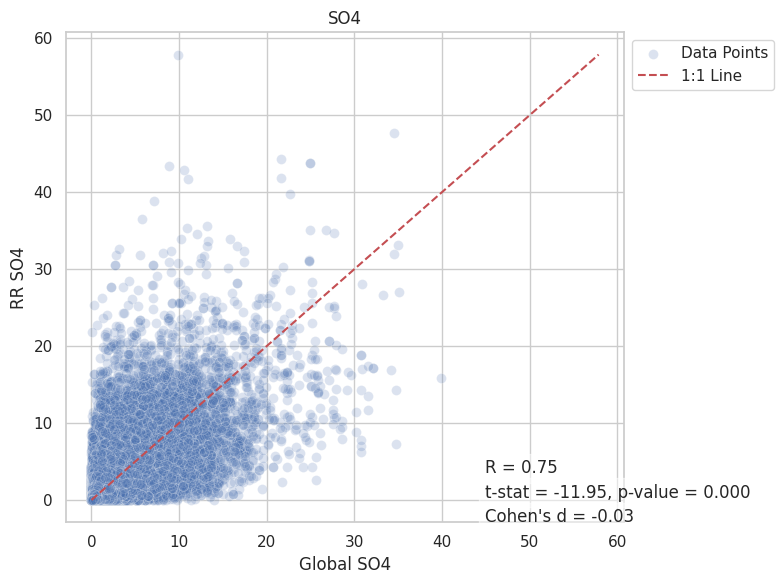

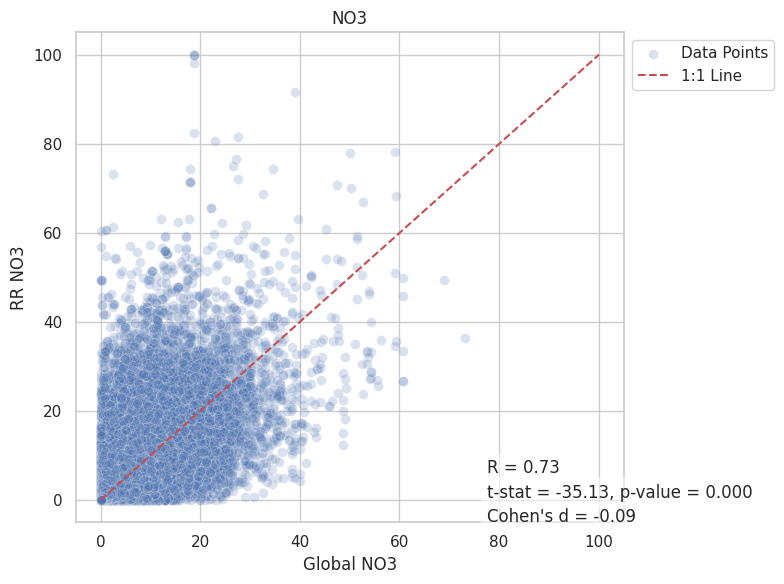

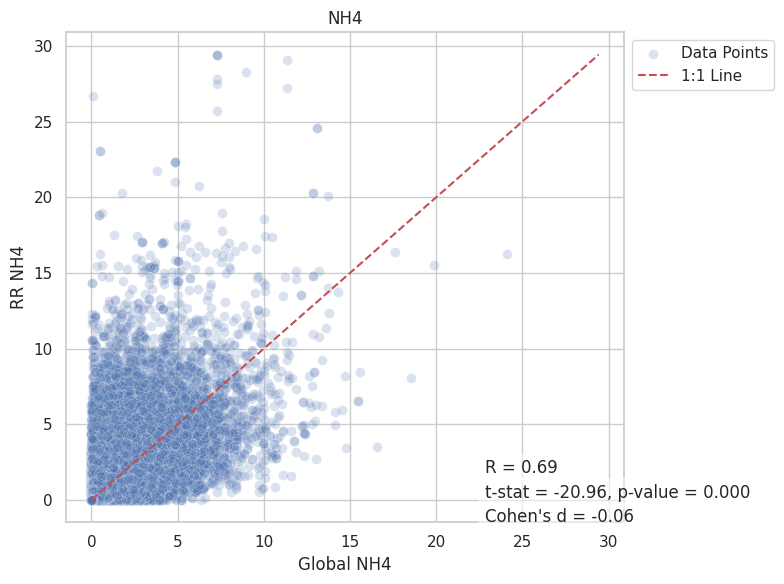

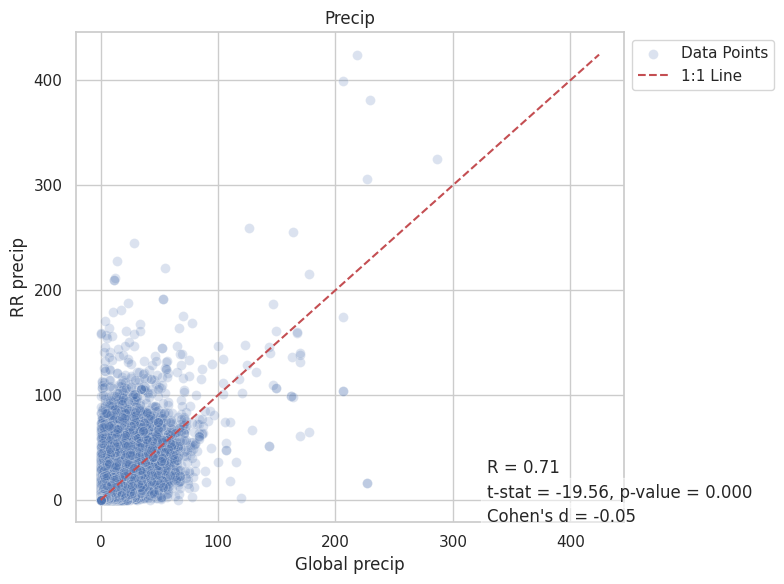

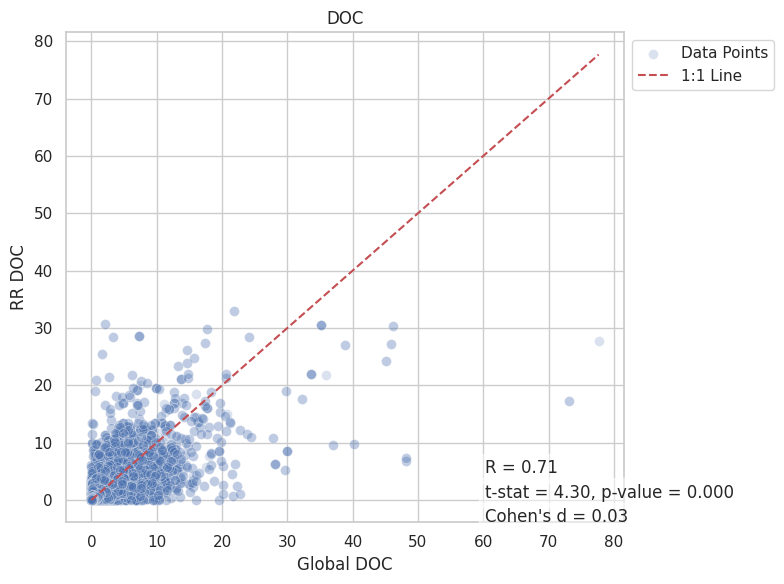

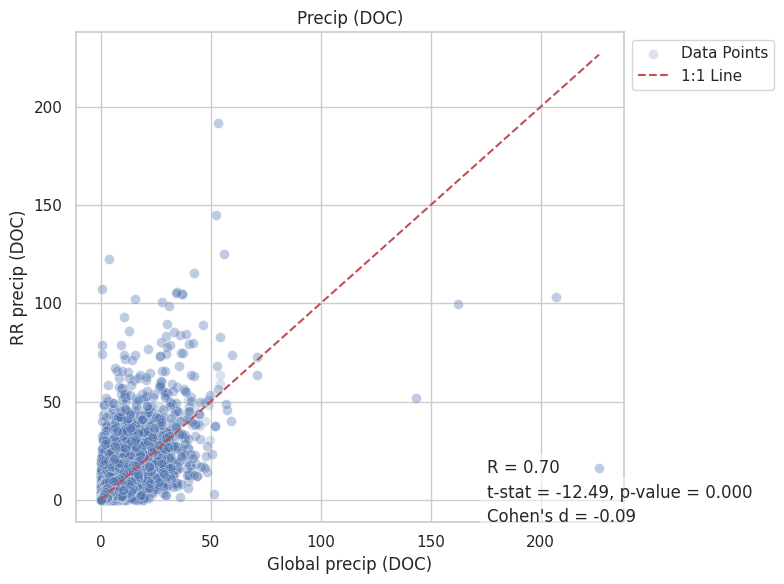

In [8]:
#Visualize data at the daily scale for each df and variable
plot_scatter_with_r(inorg_glob_RR, 'Mod_SO4_mgm2', 'Mod_SO4_mgm2_RR', xlabel='Global SO4', ylabel='RR SO4', title='SO4')
plot_scatter_with_r(inorg_glob_RR, 'Mod_NO3_mgm2', 'Mod_NO3_mgm2_RR', xlabel='Global NO3', ylabel='RR NO3', title='NO3')
plot_scatter_with_r(inorg_glob_RR, 'Mod_NH4_NH3_mgm2', 'Mod_NH4_NH3_mgm2_RR', xlabel='Global NH4', ylabel='RR NH4', title='NH4')
plot_scatter_with_r(inorg_glob_RR, 'PREC_tot_mm', 'PRECC_tot_mm_RR', xlabel='Global precip', ylabel='RR precip', title='Precip')
plot_scatter_with_r(org_glob_RR, 'Mod_SOA_POM_BC_mgm2', 'Mod_DOC_mgm2_RR', xlabel='Global DOC', ylabel='RR DOC', title='DOC')
plot_scatter_with_r(org_glob_RR, 'PREC_tot_mm', 'PRECC_tot_mm_RR', xlabel='Global precip (DOC)', ylabel='RR precip (DOC)', title='Precip (DOC)')

In [9]:
#INORGANICS: read in timeseries of: NADP NTN and ensure correct/consistent formatting

# subset for NTN comparisons: SO4, NH4, NO3 (downloaded NADP NTN 2002-2023 for all sites at weekly scale on 3/25/2024 excluding invalids)
pathData = '/glade/u/home/demurray/External File Uploads/NADP NTN wet dep data'
os.chdir(pathData)
nadp_df = pd.read_csv('NTN-ALL-Weekly 2000_2022.csv', parse_dates = ['dateOn', 'dateOff'])
ntn = pd.read_csv('ntn.csv')

#replace all negative numbers with np.nan and assign units, perform conversions
nadp_df[nadp_df.select_dtypes(include='number') < 0] = np.nan
nadp_df = nadp_df.rename(columns = {'SO4':'SO4_mgL', 'NH4':'NH4_mgL', 'NO3':'NO3_mgL', 'subppt':'ppt_mm', }) #assign units

#Scale concentrations to mg/m2 using precip volume, assuming 1mm rain = 1L/m2
nadp_df['SO4_mgm2'] = (nadp_df['SO4_mgL'] * nadp_df['ppt_mm']) 
nadp_df['NH4_mgm2'] = (nadp_df['NH4_mgL'] * nadp_df['ppt_mm'])
nadp_df['NO3_mgm2'] = (nadp_df['NO3_mgL'] * nadp_df['ppt_mm'])

#Ensure correct datetime formatting
nadp_df['dateOn'] = pd.to_datetime(nadp_df['dateOn'], format='%m/%d/%Y %H:%M')
nadp_df['dateOff'] = pd.to_datetime(nadp_df['dateOff'], format='%m/%d/%Y %H:%M')
nadp_df = nadp_df.sort_values(['siteId', 'dateOn'], ascending = True)

#Need to round date because using DAILY data for modelled comparisons
nadp_df['dateOnround'] = nadp_df.dateOn + dt.timedelta(hours=12)
nadp_df['dateOnround'] = pd.to_datetime(nadp_df.dateOnround.dt.strftime('%Y-%m-%d'))
nadp_df['dateOffround'] = nadp_df.dateOff + dt.timedelta(hours=12)
nadp_df['dateOffround'] = pd.to_datetime(nadp_df.dateOffround.dt.strftime('%Y-%m-%d'))

#Select for rows with no invalid code and only valcode of w, wa, wi, and wd (excluding trace samples and dry collection period)
nadp_df = nadp_df.loc[nadp_df['invalcode'] == '            '] #keep only the data with no invalid codes
nadp_df = nadp_df.loc[nadp_df['valcode'] !='t ',] #remove data with valid code but are trace 
nadp_df = nadp_df.loc[nadp_df['valcode'] !='d ',] #remove data with valid code but are dry
nadp_df  = nadp_df .loc[nadp_df.flagNH4 != '<',] #removed lab flagged NH4 datapoints 
nadp_df  = nadp_df .loc[nadp_df.flagNO3 != '<',] #removed lab flagged NO3 datapoints 
nadp_df  = nadp_df .loc[nadp_df.flagSO4 != '<',] #removed lab flagged SO4 datapoints 

#merge with site info and then select relevant columns
nadp_df = pd.merge(nadp_df, ntn, on = 'siteId')
nadp_df = nadp_df[['siteId','latitude', 'longitude', 'dateOn', 'dateOff', 'dateOnround', 'dateOffround', 'SO4_mgm2', 'NO3_mgm2', 'NH4_mgm2','ppt_mm']]

##Assign sampling intervals to NADP NTN deposition data
nadp_df['SamplingInt'] = pd.Series(dtype='int')
nadp_df['IntTime'] = pd.Series(dtype='int')

sites = nadp_df.siteId.unique()

for i in tqdm(sites, unit = 'sites', total = len(sites), ncols = 100):
    nadp_df.loc[nadp_df.siteId == i,'SamplingInt'] = list(range(0, len(nadp_df.loc[nadp_df.siteId == i]), 1))
    nadp_df.loc[nadp_df.siteId == i, 'IntTime'] = nadp_df.loc[nadp_df.siteId == i, 'dateOff'] - nadp_df.loc[nadp_df.siteId == i, 'dateOn']
nadp_df.head(50)

#Keep only rows where the IntTime variable is greater than 0 days and less than 31 days
nadp_df['IntTime'] = pd.to_timedelta(nadp_df['IntTime'])
nadp_df['IntDays'] = nadp_df['IntTime'].apply(round_to_nearest_day)
nadp_df = nadp_df.loc[((nadp_df['IntDays'] > 0) & (nadp_df['IntDays'] <= 31)),]

#Filter for sites that are within CONUS
lat_min, lat_max = 24.396308, 49.384358
lon_min, lon_max = -125.000000, -66.934570

# Assuming your DataFrame is named 'df' and has columns 'latitude' and 'longitude'
nadp_df = nadp_df[
    (nadp_df['latitude'] >= lat_min) &
    (nadp_df['latitude'] <= lat_max) &
    (nadp_df['longitude'] >= lon_min) &
    (nadp_df['longitude'] <= lon_max)
]

#Truncate df to 12-31-2016 to 12-31-2017 based on dateOn
start_date = '2016-12-31'
end_date = '2017-12-31'
nadp_df = nadp_df[(nadp_df['dateOnround'] >= start_date) & (nadp_df['dateOffround'] <= end_date)]


100%|██████████████████████████████████████████████████████████| 339/339 [00:13<00:00, 24.87sites/s]


In [10]:
#INORGANICS: assign sampling interval to glob/RR merged dataframes and sum to scale to weekly
inorg_glob_RR['SamplingInt'] = pd.Series(dtype='int') # Add a SamplingInt column to the modelled
sites =nadp_df.siteId.unique()

for i in tqdm(sites, unit = "sites", total = len(sites), ncols = 100):
    sampleInt = nadp_df.loc[nadp_df.siteId==i,'SamplingInt']
    #print(i)
    for j in sampleInt:
       #print(j)
       begDate = pd.Timestamp(nadp_df.loc[(nadp_df.siteId == i) & (nadp_df.SamplingInt == j), 'dateOnround'].item())
       endDate = pd.Timestamp(nadp_df.loc[(nadp_df.siteId == i) & (nadp_df.SamplingInt == j), 'dateOffround'].item())
       #print(endDate)
       inorg_glob_RR.loc[(inorg_glob_RR.siteId == i) & (inorg_glob_RR.time >= begDate) & (inorg_glob_RR.time < endDate), 'SamplingInt'] = j 

inorg_glob_RR.drop_duplicates(inplace = True)

#Sum across sampling intervals and then merge with observed data
inorg_glob_RR_sum = inorg_glob_RR.groupby(['siteId', 'SamplingInt']).sum().reset_index()
inorg_glob_RR_sum.columns

inorg_glob_RR_obs = pd.merge(nadp_df, inorg_glob_RR_sum, how = 'left', on = ['siteId', 'SamplingInt'])
len(inorg_glob_RR_obs.siteId.unique())

#Calculate precip % error
inorg_glob_RR_obs['Obs_RR_Precip_Perc_Error'] = ((abs(inorg_glob_RR_obs['PRECC_tot_mm_RR'] - inorg_glob_RR_obs['ppt_mm']))/(inorg_glob_RR_obs['PRECC_tot_mm_RR']))*100
inorg_glob_RR_obs['Obs_Glob_Precip_Perc_Error'] = ((abs(inorg_glob_RR_obs['PREC_tot_mm'] - inorg_glob_RR_obs['ppt_mm']))/(inorg_glob_RR_obs['PREC_tot_mm']))*100
inorg_glob_RR_obs = inorg_glob_RR_obs[['siteId', 'latitude', 'longitude',  'dateOnround',
       'dateOffround', 'SO4_mgm2', 'NO3_mgm2', 'NH4_mgm2', 'ppt_mm',
       'SamplingInt', 'Mod_SO4_mgm2', 'Mod_NO3_mgm2',
       'Mod_NH4_NH3_mgm2', 'PREC_tot_mm', 'PRECC_tot_mm_RR', 'Mod_SO4_mgm2_RR',
       'Mod_NH4_NH3_mgm2_RR', 'Mod_NO3_mgm2_RR', 'Obs_RR_Precip_Perc_Error',
       'Obs_Glob_Precip_Perc_Error']]
inorg_glob_RR_obs 

100%|██████████████████████████████████████████████████████████| 249/249 [01:45<00:00,  2.36sites/s]
/glade/derecho/scratch/demurray/tmp/ipykernel_42383/1540425592.py:18: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  inorg_glob_RR_sum = inorg_glob_RR.groupby(['siteId', 'SamplingInt']).sum().reset_index()


,siteId,latitude,longitude,dateOnround,dateOffround,SO4_mgm2,NO3_mgm2,NH4_mgm2,ppt_mm,SamplingInt,Mod_SO4_mgm2,Mod_NO3_mgm2,Mod_NH4_NH3_mgm2,PREC_tot_mm,PRECC_tot_mm_RR,Mod_SO4_mgm2_RR,Mod_NH4_NH3_mgm2_RR,Mod_NO3_mgm2_RR,Obs_RR_Precip_Perc_Error,Obs_Glob_Precip_Perc_Error
0,AL10,32.4583,-87.2422,2017-01-18,2017-01-25,66.248280,45.567600,16.357600,116.840,570.0,16.299502,20.435337,2.563997,44.375339,40.754309,16.465559,3.010674,30.453215,186.693611,163.299397
1,AL10,32.4583,-87.2422,2017-01-25,2017-02-01,13.774420,14.710410,3.422650,13.970,571.0,1.485242,3.842760,0.425079,0.289927,3.799565,2.999659,0.533715,5.871976,267.673660,4718.451453
2,AL10,32.4583,-87.2422,2017-02-01,2017-02-08,11.124692,8.676640,3.393186,15.494,572.0,9.975179,11.160791,1.121906,12.273729,45.309563,7.431907,1.793792,15.496647,65.804128,26.237102
3,AL10,32.4583,-87.2422,2017-02-08,2017-02-15,27.322272,17.666208,5.486400,36.576,573.0,0.934579,1.345565,0.207854,0.268522,0.856072,1.551449,1.196360,4.749275,4172.535988,13521.244028
4,AL10,32.4583,-87.2422,2017-02-15,2017-02-22,8.031480,5.302504,2.141728,8.636,574.0,9.069300,12.542332,1.481397,24.206085,49.031749,13.128894,2.313958,19.901346,82.386922,64.323020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8212,WY99,43.8730,-104.1917,2017-11-01,2017-11-08,3.007868,5.322824,2.047240,15.748,546.0,2.634324,14.431122,3.425682,12.059067,21.277105,4.780076,4.279697,18.820072,25.986173,30.590533
8213,WY99,43.8730,-104.1917,2017-11-22,2017-11-29,0.060198,0.092964,0.092202,0.762,547.0,0.027416,0.543620,0.084379,0.710215,1.485796,0.361250,0.151823,0.912386,48.714358,7.291471
8214,WY99,43.8730,-104.1917,2017-11-29,2017-12-06,4.322064,7.722108,1.437132,1.524,548.0,0.860401,6.617358,1.184825,4.053173,4.119839,1.047641,0.554085,5.022237,63.008259,62.399824
8215,WY99,43.8730,-104.1917,2017-12-13,2017-12-21,1.273556,7.945120,1.331976,11.684,549.0,1.191022,3.169425,1.040078,8.907330,5.838538,2.259749,0.708284,6.107197,100.118604,31.172863


In [11]:
#ORGANICS: read in timeseries of: DOC data and ensure correct/consistent formatting
doc_df = pd.read_csv('/glade/u/home/demurray/External File Uploads/DOC data/DOC_wetdep_compiled.csv', parse_dates = ['dateOn', 'dateOff'])

#Scale concentrations to mg/m2 using precip volume, assuming 1mm rain = 1L/m2
doc_df['DOC_mgm2'] = (doc_df['DOC_mgL'] * doc_df['Precip_mm']) 

#Ensure correct datetime formatting
doc_df = doc_df.sort_values(['siteId', 'dateOn'], ascending = True)

#Need to round date because using DAILY data for modelled comparisons
doc_df['dateOnround'] = doc_df.dateOn + dt.timedelta(hours=12)
doc_df['dateOnround'] = pd.to_datetime(doc_df.dateOnround.dt.strftime('%Y-%m-%d'))
doc_df['dateOffround'] = doc_df.dateOff + dt.timedelta(hours=12)
doc_df['dateOffround'] = pd.to_datetime(doc_df.dateOffround.dt.strftime('%Y-%m-%d'))
doc_df = doc_df[['siteId',  'latitude', 'longitude', 'dateOn', 'dateOff', 'dateOnround', 'dateOffround', 'Precip_mm', 'DOC_mgm2']]

##Assign sampling intervals to NADP NTN deposition data
doc_df['SamplingInt'] = pd.Series(dtype='int')
doc_df['IntTime'] = pd.Series(dtype='int')

sites = doc_df.siteId.unique()

for i in tqdm(sites, unit = 'sites', total = len(sites), ncols = 100):
    doc_df.loc[doc_df.siteId == i,'SamplingInt'] = list(range(0, len(doc_df.loc[doc_df.siteId == i]), 1))
    doc_df.loc[doc_df.siteId == i, 'IntTime'] = doc_df.loc[doc_df.siteId == i, 'dateOff'] - doc_df.loc[doc_df.siteId == i, 'dateOn']

#Filter for sites that are within CONUS
lat_min, lat_max = 24.396308, 49.384358
lon_min, lon_max = -125.000000, -66.934570

# Assuming your DataFrame is named 'df' and has columns 'latitude' and 'longitude'
doc_df = doc_df[
    (doc_df['latitude'] >= lat_min) &
    (doc_df['latitude'] <= lat_max) &
    (doc_df['longitude'] >= lon_min) &
    (doc_df['longitude'] <= lon_max)
]

#Truncate df to 12-31-2016 to 12-31-2017 based on dateOn
start_date = '2016-12-31'
end_date = '2017-12-31'
doc_df = doc_df[(doc_df['dateOnround'] >= start_date) & (doc_df['dateOffround'] <= end_date)]

#Keep only rows where the IntTime variable is greater than 0 days and less than 31 days
doc_df['IntTime'] = pd.to_timedelta(doc_df['IntTime'])
doc_df['IntDays'] = doc_df['IntTime'].apply(round_to_nearest_day)
doc_df = doc_df.loc[((doc_df['IntDays'] > 0) & (doc_df['IntDays'] <= 31)),]

len(doc_df.siteId.unique())

100%|███████████████████████████████████████████████████████████| 24/24 [00:00<00:00, 571.85sites/s]


17

In [12]:
#ORGANICS: assign sampling interval to glob/RR merged dataframes and sum to scale to weekly
org_glob_RR['SamplingInt'] = pd.Series(dtype='int') # Add a SamplingInt column to the modelled
sites =doc_df.siteId.unique()

for i in tqdm(sites, unit = "sites", total = len(sites), ncols = 100):
    sampleInt = doc_df.loc[doc_df.siteId==i,'SamplingInt']
    #print(i)
    for j in sampleInt:
       #print(j)
       begDate = pd.Timestamp(doc_df.loc[(doc_df.siteId == i) & (doc_df.SamplingInt == j), 'dateOnround'].item())
       endDate = pd.Timestamp(doc_df.loc[(doc_df.siteId == i) & (doc_df.SamplingInt == j), 'dateOffround'].item())
       #print(endDate)
       org_glob_RR.loc[(org_glob_RR.siteId == i) & (org_glob_RR.time >= begDate) & (org_glob_RR.time < endDate), 'SamplingInt'] = j 

org_glob_RR.drop_duplicates(inplace = True)

#Sum across sampling intervals and then merge with observed data
org_glob_RR_sum = org_glob_RR.groupby(['siteId', 'SamplingInt']).sum().reset_index()
org_glob_RR_sum.columns

org_glob_RR_obs = pd.merge(doc_df, org_glob_RR_sum, how = 'left', on = ['siteId', 'SamplingInt'])
org_glob_RR_obs.columns


100%|████████████████████████████████████████████████████████████| 17/17 [00:00<00:00, 48.57sites/s]
/glade/derecho/scratch/demurray/tmp/ipykernel_42383/2272542121.py:18: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  org_glob_RR_sum = org_glob_RR.groupby(['siteId', 'SamplingInt']).sum().reset_index()


Index(['siteId', 'latitude', 'longitude', 'dateOn', 'dateOff', 'dateOnround',
       'dateOffround', 'Precip_mm', 'DOC_mgm2', 'SamplingInt', 'IntTime',
       'IntDays', 'PRECC_tot_mm_RR', 'Mod_DOC_mgm2_RR', 'Mod_SOA_POM_BC_mgm2',
       'PREC_tot_mm'],
      dtype='object')

In [13]:
#Create individual dataframes for dropping nans 

################# Inorganics
SO4_df = inorg_glob_RR_obs[['siteId', 'SamplingInt', 'dateOnround', 'dateOffround', 'latitude', 'longitude', 'Mod_SO4_mgm2_RR', 'Mod_SO4_mgm2', 'SO4_mgm2']].dropna()
SO4_df['Variable'] = 'WetDep_SO4_mgm2'
SO4_df = SO4_df.rename(columns = {'Mod_SO4_mgm2':'Modelled_global', 'Mod_SO4_mgm2_RR': 'Modelled_RR', 'SO4_mgm2' : 'Observed'})
SO4_df

NO3_df =  inorg_glob_RR_obs[['siteId', 'SamplingInt', 'dateOnround', 'dateOffround', 'latitude', 'longitude', 'Mod_NO3_mgm2_RR', 'Mod_NO3_mgm2', 'NO3_mgm2']].dropna()
NO3_df['Variable'] = 'WetDep_NO3_mgm2'
NO3_df = NO3_df.rename(columns = {'Mod_NO3_mgm2':'Modelled_global', 'Mod_NO3_mgm2_RR': 'Modelled_RR', 'NO3_mgm2' : 'Observed'})

NH4_df =  inorg_glob_RR_obs[['siteId', 'SamplingInt', 'dateOnround', 'dateOffround', 'latitude', 'longitude','Mod_NH4_NH3_mgm2_RR', 'Mod_NH4_NH3_mgm2', 'NH4_mgm2']].dropna()
NH4_df['Variable'] = 'WetDep_NH4_mgm2'
NH4_df = NH4_df.rename(columns = {'Mod_NH4_NH3_mgm2':'Modelled_global', 'Mod_NH4_NH3_mgm2_RR': 'Modelled_RR', 'NH4_mgm2' : 'Observed'})

DOC_df = org_glob_RR_obs[['siteId','SamplingInt', 'dateOnround', 'dateOffround', 'latitude', 'longitude', 'DOC_mgm2', 'Mod_DOC_mgm2_RR', 'Mod_SOA_POM_BC_mgm2']].dropna()
DOC_df['Variable'] = 'WetDep_DOC_mgm2'
DOC_df = DOC_df.rename(columns = {'Mod_SOA_POM_BC_mgm2':'Modelled_global', 'Mod_DOC_mgm2_RR': 'Modelled_RR', 'DOC_mgm2' : 'Observed'})

#Add inorganics precipitation data
ppt_df_inorg = inorg_glob_RR_obs[['siteId', 'SamplingInt', 'dateOnround', 'dateOffround', 'latitude', 'longitude', 'PRECC_tot_mm_RR', 'PREC_tot_mm', 'ppt_mm']].dropna()
ppt_df_inorg = ppt_df_inorg.rename(columns = {'PREC_tot_mm':'Modelled_global', 'PRECC_tot_mm_RR':'Modelled_RR', 'ppt_mm' : 'Observed'})
ppt_df_inorg['Variable'] = 'Precipitation_mm'

#Add organics precipitation data
ppt_df_org = org_glob_RR_obs[['siteId', 'SamplingInt', 'dateOnround', 'dateOffround', 'latitude', 'longitude','Precip_mm','PRECC_tot_mm_RR', 'PREC_tot_mm']].dropna()
ppt_df_org = ppt_df_org.rename(columns = {'PREC_tot_mm':'Modelled_global', 'PRECC_tot_mm_RR':'Modelled_RR', 'Precip_mm' : 'Observed'})
ppt_df_org['Variable'] = 'Precipitation_mm'

#Final df creation
glob_RR_obs_clean = pd.concat([SO4_df, NO3_df, NH4_df, DOC_df, ppt_df_inorg, ppt_df_org])

#Calculate percent error between Modeled and Observed data and assign precip percent error to each observation
glob_RR_obs_clean['Percent_Error_RR'] = ((abs(glob_RR_obs_clean['Modelled_RR'] - glob_RR_obs_clean['Observed']))/(glob_RR_obs_clean['Modelled_RR']))*100
glob_RR_obs_clean['Percent_Error_global'] = ((abs(glob_RR_obs_clean['Modelled_global'] - glob_RR_obs_clean['Observed']))/(glob_RR_obs_clean['Modelled_global']))*100
glob_RR_obs_clean.drop_duplicates(inplace = True)
glob_RR_obs_clean

,siteId,SamplingInt,dateOnround,dateOffround,latitude,longitude,Modelled_RR,Modelled_global,Observed,Variable,Percent_Error_RR,Percent_Error_global
0,AL10,570.0,2017-01-18,2017-01-25,32.4583,-87.2422,16.465559,16.299502,66.248280,WetDep_SO4_mgm2,302.344561,306.443586
1,AL10,571.0,2017-01-25,2017-02-01,32.4583,-87.2422,2.999659,1.485242,13.774420,WetDep_SO4_mgm2,359.199472,827.419125
2,AL10,572.0,2017-02-01,2017-02-08,32.4583,-87.2422,7.431907,9.975179,11.124692,WetDep_SO4_mgm2,49.688249,11.523728
3,AL10,573.0,2017-02-08,2017-02-15,32.4583,-87.2422,1.551449,0.934579,27.322272,WetDep_SO4_mgm2,1661.080467,2823.483292
4,AL10,574.0,2017-02-15,2017-02-22,32.4583,-87.2422,13.128894,9.069300,8.031480,WetDep_SO4_mgm2,38.825919,11.443216
...,...,...,...,...,...,...,...,...,...,...,...,...
159,WY08,0.0,2017-01-05,2017-01-11,44.9166,-110.4203,14.328715,12.987751,15.494000,Precipitation_mm,8.132515,19.297024
160,WY08,1.0,2017-03-21,2017-03-28,44.9166,-110.4203,11.936468,9.709972,14.224000,Precipitation_mm,19.164226,46.488572
161,WY08,2.0,2017-05-16,2017-05-23,44.9166,-110.4203,12.214934,37.683866,25.400000,Precipitation_mm,107.942177,32.597149
162,WY08,3.0,2017-09-13,2017-09-20,44.9166,-110.4203,51.277009,51.328637,57.150000,Precipitation_mm,11.453458,11.341356


In [14]:
#Assigning precip percent error to all values in df
ppt_qual = pd.concat([ppt_df_org, ppt_df_inorg]).drop_duplicates()

#Assigning precip percent error to all values in df
ppt_qual['Precip_Percent_Error_RR'] = ((abs(ppt_qual['Modelled_RR'] - ppt_qual['Observed']))/(ppt_qual['Modelled_RR']))*100
ppt_qual['Precip_Percent_Error_global'] = ((abs(ppt_qual['Modelled_global'] - ppt_qual['Observed']))/(ppt_qual['Modelled_global']))*100
ppt_qual = ppt_qual[['siteId', 'SamplingInt', 'dateOnround', 'dateOffround', 'latitude', 'longitude', 'Precip_Percent_Error_RR', 'Precip_Percent_Error_global']]
ppt_qual

#Merge with clean df
glob_RR_obs_clean = pd.merge(glob_RR_obs_clean, ppt_qual, on = ['siteId', 'SamplingInt', 'dateOnround', 'dateOffround', 'latitude', 'longitude'])
glob_RR_obs_clean

,siteId,SamplingInt,dateOnround,dateOffround,latitude,longitude,Modelled_RR,Modelled_global,Observed,Variable,Percent_Error_RR,Percent_Error_global,Precip_Percent_Error_RR,Precip_Percent_Error_global
0,AL10,570.0,2017-01-18,2017-01-25,32.4583,-87.2422,16.465559,16.299502,66.24828,WetDep_SO4_mgm2,302.344561,306.443586,186.693611,163.299397
1,AL10,570.0,2017-01-18,2017-01-25,32.4583,-87.2422,30.453215,20.435337,45.56760,WetDep_NO3_mgm2,49.631492,122.984333,186.693611,163.299397
2,AL10,570.0,2017-01-18,2017-01-25,32.4583,-87.2422,3.010674,2.563997,16.35760,WetDep_NH4_mgm2,443.320222,537.972640,186.693611,163.299397
3,AL10,570.0,2017-01-18,2017-01-25,32.4583,-87.2422,40.754309,44.375339,116.84000,Precipitation_mm,186.693611,163.299397,186.693611,163.299397
4,AL10,571.0,2017-01-25,2017-02-01,32.4583,-87.2422,2.999659,1.485242,13.77442,WetDep_SO4_mgm2,359.199472,827.419125,267.673660,4718.451453
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33179,WY08,2.0,2017-05-16,2017-05-23,44.9166,-110.4203,12.214934,37.683866,25.40000,Precipitation_mm,107.942177,32.597149,107.942177,32.597149
33180,WY08,3.0,2017-09-13,2017-09-20,44.9166,-110.4203,13.839746,38.881276,34.86150,WetDep_DOC_mgm2,151.894067,10.338590,11.453458,11.341356
33181,WY08,3.0,2017-09-13,2017-09-20,44.9166,-110.4203,51.277009,51.328637,57.15000,Precipitation_mm,11.453458,11.341356,11.453458,11.341356
33182,WY08,4.0,2017-11-14,2017-11-22,44.9166,-110.4203,1.555425,0.813068,6.72084,WetDep_DOC_mgm2,332.090259,726.601993,30.695082,1.908294


In [15]:
#dat = glob_RR_obs_clean.loc[glob_RR_obs_clean['Variable'] == 'WetDep_DOC_mgm2',]
dat = glob_RR_obs_clean.loc[glob_RR_obs_clean['Variable'] != 'WetDep_DOC_mgm2',]
run_statistics(dat, "glob_RR_obs_clean")

Unique site count for glob_RR_obs_clean:
 Variable
Precipitation_mm    250
WetDep_NH4_mgm2     249
WetDep_NO3_mgm2     249
WetDep_SO4_mgm2     249
Name: siteId, dtype: int64

Observation count for glob_RR_obs_clean:
 Variable
Precipitation_mm    8381
WetDep_NH4_mgm2     8212
WetDep_NO3_mgm2     8214
WetDep_SO4_mgm2     8213
Name: Modelled_global, dtype: int64

Average number of observations per site for glob_RR_obs_clean:
 33.11935807422267


In [16]:
#Assign percentile error threhsolds to determine the %error threshold below which 90% of the data sits
glob_RR_obs_clean = glob_RR_obs_clean.dropna(subset = 'Precip_Percent_Error_RR')
glob_RR_obs_clean = glob_RR_obs_clean.dropna(subset = 'Precip_Percent_Error_global')

#First do this for the RR model and observed#####
#Total data counts
total_count_RR = glob_RR_obs_clean.groupby('Variable')[['Precip_Percent_Error_RR']].count().reset_index()
total_count_RR['90_perc_RR'] = total_count_RR['Precip_Percent_Error_RR']*0.9
total_count_RR = total_count_RR.rename(columns = {'Precip_Percent_Error_RR' : 'Total_count_RR'})

# Define the bins
bins = pd.interval_range(start=0, end=1000, freq=10)
bin_labels = [int(interval.left) for interval in bins]
glob_RR_obs_clean['Error_bin_RR'] = pd.cut(glob_RR_obs_clean['Precip_Percent_Error_RR'],bins=bins,labels=bin_labels,include_lowest=True)

#Group by variable and simple error bin and count
variable_bin_count_RR = glob_RR_obs_clean.groupby(['Variable', 'Error_bin_RR'])['Precip_Percent_Error_RR'].count().reset_index()
variable_bin_count_RR = variable_bin_count_RR.rename(columns = {'Precip_Percent_Error_RR' : 'Bin_count_RR'})

all_count_RR = pd.merge(variable_bin_count_RR, total_count_RR, on = 'Variable', how = 'left')
all_count_RR.to_csv('/glade/u/home/demurray/Murray-NCAR-GVP/MUSICA Analyses/Data outputs/RR Bin Precip Percent Error Count.csv')

#Then do this for the global model and observed#####
total_count_glob = glob_RR_obs_clean.groupby('Variable')[['Precip_Percent_Error_global']].count().reset_index()
total_count_glob['90_perc_global'] = total_count_glob['Precip_Percent_Error_global']*0.9
total_count_glob = total_count_glob.rename(columns = {'Precip_Percent_Error_global' : 'Total_count_global'})

# Define the bins
glob_RR_obs_clean['Error_bin_global'] = pd.cut(glob_RR_obs_clean['Precip_Percent_Error_global'],bins=bins,labels=bin_labels,include_lowest=True)

#Group by variable and simple error bin and count
variable_bin_count_glob = glob_RR_obs_clean.groupby(['Variable', 'Error_bin_global'])['Precip_Percent_Error_global'].count().reset_index()
variable_bin_count_glob = variable_bin_count_glob.rename(columns = {'Precip_Percent_Error_global' : 'Bin_count_global'})

all_count_glob = pd.merge(variable_bin_count_glob, total_count_glob, on = 'Variable', how = 'left')
all_count_glob.to_csv('/glade/u/home/demurray/Murray-NCAR-GVP/MUSICA Analyses/Data outputs/Global trunc Bin Precip Percent Error Count.csv')

In [21]:
#Classify whether each data point has a %error threshold below the 90% threshold for RR and global, individually

#90% data retention Global truncated, 'Precip_Percent_Error_global'
#no3, nh4, so4 = less than 360; doc = less than 440
glob_RR_obs_clean['Below_90_glob'] = np.where(
    ((glob_RR_obs_clean.Variable == 'WetDep_DOC_mgm2') & (glob_RR_obs_clean.Precip_Percent_Error_global < 360)), 'Y',
    np.where(((glob_RR_obs_clean.Variable != 'WetDep_DOC_mgm2') & (glob_RR_obs_clean.Precip_Percent_Error_global < 440)), 'Y', 'N'))

#90% data retention RR
#no3, nh4, so4 = 260; doc = 240
glob_RR_obs_clean['Below_90_RR'] = np.where(
    ((glob_RR_obs_clean.Variable == 'WetDep_DOC_mgm2') & (glob_RR_obs_clean.Precip_Percent_Error_RR < 240)), 'Y',
    np.where(((glob_RR_obs_clean.Variable != 'WetDep_DOC_mgm2') & (glob_RR_obs_clean.Precip_Percent_Error_RR < 260)), 'Y', 'N'))
glob_RR_obs_clean

,siteId,SamplingInt,dateOnround,dateOffround,latitude,longitude,Modelled_RR,Modelled_global,Observed,Variable,Percent_Error_RR,Percent_Error_global,Precip_Percent_Error_RR,Precip_Percent_Error_global,Error_bin_RR,Error_bin_global,Below_90_glob,Below_90_RR
0,AL10,570.0,2017-01-18,2017-01-25,32.4583,-87.2422,16.465559,16.299502,66.24828,WetDep_SO4_mgm2,302.344561,306.443586,186.693611,163.299397,"(180, 190]","(160.0, 170.0]",Y,Y
1,AL10,570.0,2017-01-18,2017-01-25,32.4583,-87.2422,30.453215,20.435337,45.56760,WetDep_NO3_mgm2,49.631492,122.984333,186.693611,163.299397,"(180, 190]","(160.0, 170.0]",Y,Y
2,AL10,570.0,2017-01-18,2017-01-25,32.4583,-87.2422,3.010674,2.563997,16.35760,WetDep_NH4_mgm2,443.320222,537.972640,186.693611,163.299397,"(180, 190]","(160.0, 170.0]",Y,Y
3,AL10,570.0,2017-01-18,2017-01-25,32.4583,-87.2422,40.754309,44.375339,116.84000,Precipitation_mm,186.693611,163.299397,186.693611,163.299397,"(180, 190]","(160.0, 170.0]",Y,Y
4,AL10,571.0,2017-01-25,2017-02-01,32.4583,-87.2422,2.999659,1.485242,13.77442,WetDep_SO4_mgm2,359.199472,827.419125,267.673660,4718.451453,"(260, 270]",NaN,N,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33179,WY08,2.0,2017-05-16,2017-05-23,44.9166,-110.4203,12.214934,37.683866,25.40000,Precipitation_mm,107.942177,32.597149,107.942177,32.597149,"(100, 110]","(30.0, 40.0]",Y,Y
33180,WY08,3.0,2017-09-13,2017-09-20,44.9166,-110.4203,13.839746,38.881276,34.86150,WetDep_DOC_mgm2,151.894067,10.338590,11.453458,11.341356,"(10, 20]","(10.0, 20.0]",Y,Y
33181,WY08,3.0,2017-09-13,2017-09-20,44.9166,-110.4203,51.277009,51.328637,57.15000,Precipitation_mm,11.453458,11.341356,11.453458,11.341356,"(10, 20]","(10.0, 20.0]",Y,Y
33182,WY08,4.0,2017-11-14,2017-11-22,44.9166,-110.4203,1.555425,0.813068,6.72084,WetDep_DOC_mgm2,332.090259,726.601993,30.695082,1.908294,"(30, 40]","(0.0, 10.0]",Y,Y


In [22]:
#Filter dataframe for points where Below_90_glob and Below_90_RR are both 'Y'
glob_RR_obs_clean_filter = glob_RR_obs_clean.loc[((glob_RR_obs_clean.Below_90_glob == 'Y') & (glob_RR_obs_clean.Below_90_RR == 'Y')),]
glob_RR_obs_clean_filter # ~ 13% data reduction

#dat = glob_RR_obs_clean_filter.loc[glob_RR_obs_clean_filter['Variable'] == 'WetDep_DOC_mgm2',]
dat = glob_RR_obs_clean_filter.loc[glob_RR_obs_clean_filter['Variable'] != 'WetDep_DOC_mgm2',]
run_statistics(dat, "glob_RR_obs_clean_filter")

Unique site count for glob_RR_obs_clean_filter:
 Variable
Precipitation_mm    249
WetDep_NH4_mgm2     248
WetDep_NO3_mgm2     248
WetDep_SO4_mgm2     248
Name: siteId, dtype: int64

Observation count for glob_RR_obs_clean_filter:
 Variable
Precipitation_mm    7284
WetDep_NH4_mgm2     7139
WetDep_NO3_mgm2     7141
WetDep_SO4_mgm2     7140
Name: Modelled_global, dtype: int64

Average number of observations per site for glob_RR_obs_clean_filter:
 28.906344410876134


In [23]:
glob_RR_obs_clean_filter.columns
glob_RR_obs_clean_filter[['siteId', 'SamplingInt', 'dateOnround', 'dateOffround', 'latitude',
       'longitude', 'Variable', 'Observed', 'Modelled_RR', 'Modelled_global', 
       'Percent_Error_RR', 'Percent_Error_global', 'Precip_Percent_Error_RR',
       'Precip_Percent_Error_global']]
glob_RR_obs_clean_filter.to_csv('/glade/u/home/demurray/Murray-NCAR-GVP/MUSICA Analyses/Data outputs/Clean and filtered RR Glob Obs timeseries.csv')